In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

plt.style.use('seaborn-v0_8')
print("All imports successful")

All imports successful


In [2]:
# Load and explore the dataset
df = pd.read_csv('../data/raw/Crop_recommendation.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nCrop types ({df['label'].nunique()} total):")
print(df['label'].value_counts())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic stats:")
df.describe()

Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Crop types (22 total):
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Basic stats:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


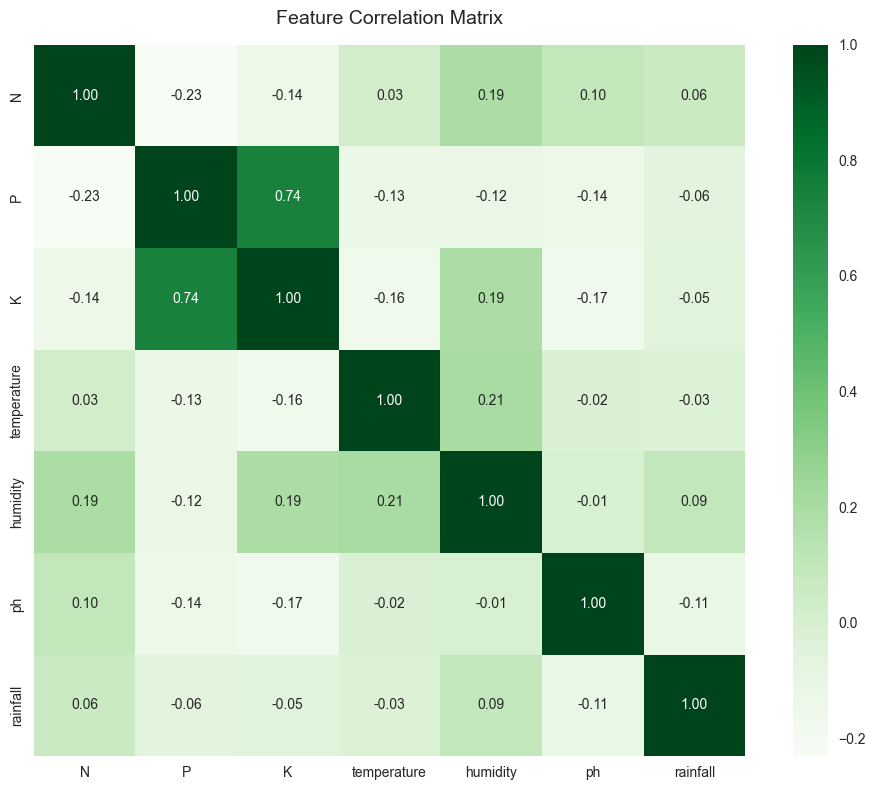

Saved to assets/correlation_heatmap.png


In [3]:
# Correlation heatmap — screenshot this for your README
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.drop('label', axis=1).corr(),
    annot=True,
    fmt='.2f',
    cmap='Greens',
    square=True
)
plt.title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../assets/correlation_heatmap.png', dpi=150)
plt.show()
print("Saved to assets/correlation_heatmap.png")

In [4]:
# Prepare features and target
X = df.drop('label', axis=1)
y = df['label']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(rf, X_scaled, y, cv=5)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Cross-validation: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 99.55%
Cross-validation: 99.50% ± 0.36%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
  

✅ Model saved to app/models/crop_model.pkl
✅ Scaler saved to app/models/scaler.pkl


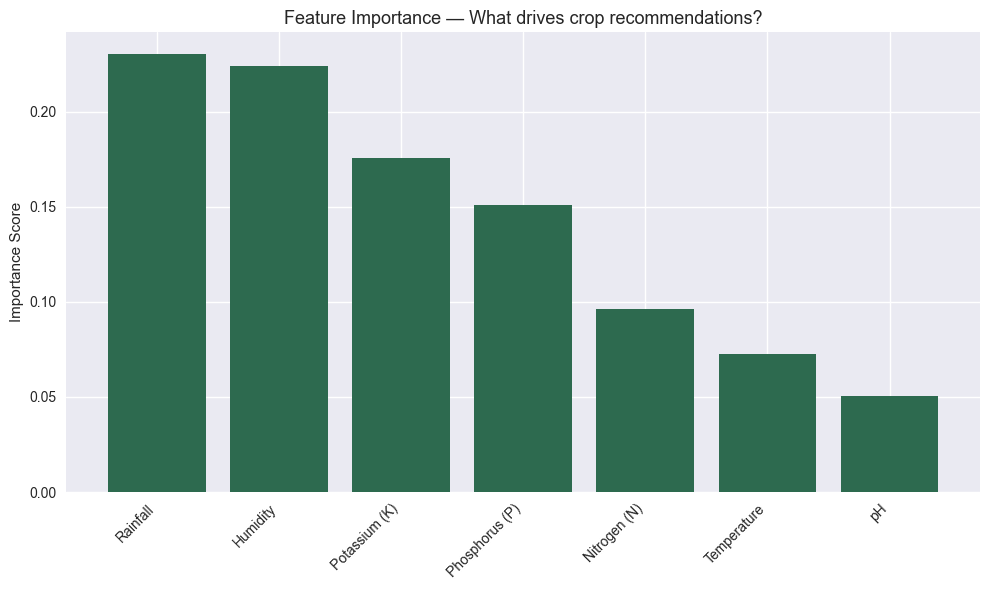

✅ Saved to assets/feature_importance.png


In [5]:
# Save model and scaler for the Flask API
joblib.dump(rf, '../app/models/crop_model.pkl')
joblib.dump(scaler, '../app/models/scaler.pkl')
print("✅ Model saved to app/models/crop_model.pkl")
print("✅ Scaler saved to app/models/scaler.pkl")

# Feature importance chart — also goes in README
feature_names = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)', 
                 'Temperature', 'Humidity', 'pH', 'Rainfall']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importances[indices], color='#2d6a4f')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance — What drives crop recommendations?', fontsize=13)
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150)
plt.show()
print("✅ Saved to assets/feature_importance.png")